In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl
import pandas as pd

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)

Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- product_category_name_translation


In [2]:
import pandas as pd

# Cargar tablas (ejemplo usando SQLAlchemy engine)
customers = pd.read_sql("SELECT * FROM olist_customers_dataset", con=engine)
orders = pd.read_sql("SELECT * FROM olist_orders_dataset", con=engine)
order_items = pd.read_sql("SELECT * FROM olist_order_items_dataset", con=engine)
order_payments = pd.read_sql("SELECT * FROM olist_order_payments_dataset", con=engine)
order_reviews = pd.read_sql("SELECT * FROM olist_order_reviews_dataset", con=engine)
products = pd.read_sql("SELECT * FROM olist_products_dataset", con=engine)
product_cat = pd.read_sql("SELECT * FROM product_category_name_translation", con=engine)
sellers = pd.read_sql("SELECT * FROM olist_sellers_dataset", con=engine)
geo = pd.read_sql("SELECT * FROM olist_geolocation_dataset", con=engine)

In [4]:
# Función para explorar de forma rápida una tabla SQL:
# carga los datos, convierte posibles columnas de fechas y muestra dimensiones, tipos, nulos, duplicados y primeras filas
def explore_table(table, n=5):
    df = pd.read_sql_query(f"SELECT * FROM `{table}`", con=engine)
    
    for col in df.columns:
        if "date" in col.lower() or "timestamp" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")
    
    print(f"Tabla: {table}")
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    display(df.dtypes)
    print("\nValores nulos por columna:")
    display(df.isnull().sum())
    print("\nDuplicados (filas completas):", df.duplicated().sum())
    
    print(f"\nPrimeras {n} filas:")
    display(df.head(n))
    
    return df

### 7. TABLA: olist_products_dataset

In [9]:
# Exploramos products
df_products = explore_table("olist_products_dataset")

Tabla: olist_products_dataset
Dimensiones: (32951, 10)

Tipos de datos:


id                              int64
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


Valores nulos por columna:


id                              0
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### 3. TABLA: olist_order_items_dataset

In [5]:
# Exploramos order_items
df_order_items = explore_table("olist_order_items_dataset")

Tabla: olist_order_items_dataset
Dimensiones: (112650, 8)

Tipos de datos:


id                              int64
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


Valores nulos por columna:


id                     0
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,112650,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79
1,112649,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
2,112648,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
3,112647,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
4,112646,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41


### TABLA: olist_orders_dataset

In [6]:
# Exploramos orders
df_orders = explore_table("olist_orders_dataset")

Tabla: olist_orders_dataset
Dimensiones: (99441, 9)

Tipos de datos:


id                                        int64
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Valores nulos por columna:


id                                  0
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


### 9. TABLA: product_category_name_translation

In [7]:
# Exploramos product_category_name_translation
df_product_cat = explore_table("product_category_name_translation")

Tabla: product_category_name_translation
Dimensiones: (71, 3)

Tipos de datos:


id                                int64
product_category_name            object
product_category_name_english    object
dtype: object


Valores nulos por columna:


id                               0
product_category_name            0
product_category_name_english    0
dtype: int64


Duplicados (filas completas): 0

Primeras 5 filas:


,id,product_category_name,product_category_name_english
0,1,beleza_saude,health_beauty
1,2,informatica_acessorios,computers_accessories
2,3,automotivo,auto
3,4,cama_mesa_banho,bed_bath_table
4,5,moveis_decoracao,furniture_decor


# Análisis de si la longitud del título, longitud de la descripción y nº de fotos de un producto influye en que se venda más (por el posicionamiento) 

In [10]:
#comprobar nulos df products
df_products[df_products.isnull().any(axis=1)]

,id,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,106,a41e356c76fab66334f36de622ecbd3a,None,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,129,d8dee61c2034d6d075997acef1870e9b,None,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,146,56139431d72cd51f19eb9f7dae4d1617,None,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,155,46b48281eb6d663ced748f324108c733,None,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,198,5fb61f482620cb672f5e586bb132eae9,None,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...,...
32515,32516,b0a0c5dd78e644373b199380612c350a,None,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,32590,10dbe0fbaa2c505123c17fdc34a63c56,None,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,32617,bd2ada37b58ae94cc838b9c0569fecd8,None,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,32773,fa51e914046aab32764c41356b9d4ea4,None,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [11]:
# Eliminar productos sin categoría (y por tanto sin descripción ni fotos)
df_products_clean = df_products.dropna(subset=['product_category_name']).copy()

# Comprobar resultado
df_products_clean.isnull().sum()

id                            0
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
dtype: int64

In [12]:
# Unimos las tablas de items, pedidos y productos para crear un DataFrame con toda la información relevante de ventas y características del producto
df_ventas_productos = (
    df_order_items
    .merge(df_orders[['order_id', 'order_status']], on='order_id', how='inner')
    .merge(
        df_products_clean[['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']],
        on='product_id',
        how='left'
    )
)

In [13]:
df_ventas_productos.head()

,id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,product_name_lenght,product_description_lenght,product_photos_qty
0,112650,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,delivered,47.0,511.0,1.0
1,112649,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,delivered,56.0,1306.0,1.0
2,112648,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,delivered,43.0,869.0,1.0
3,112647,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,delivered,31.0,232.0,1.0
4,112646,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,delivered,43.0,1002.0,3.0


In [14]:
# Calculamos el número total de ventas por producto agrupando por su id
ventas_por_producto = (
    df_order_items
    .groupby('product_id')
    .size()
    .reset_index(name='num_ventas')
)

ventas_por_producto

,product_id,num_ventas
0,00066f42aeeb9f3007548bb9d3f33c38,1
1,00088930e925c41fd95ebfe695fd2655,1
2,0009406fd7479715e4bef61dd91f2462,1
3,000b8f95fcb9e0096488278317764d19,2
4,000d9be29b5207b54e86aa1b1ac54872,1
...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,2
32947,fff81cc3158d2725c0655ab9ba0f712c,1
32948,fff9553ac224cec9d15d49f5a263411f,1
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,5


In [15]:
# Unimos el número de ventas por producto con el dataset de productos limpios para añadir sus características
productos_ventas = ventas_por_producto.merge(
    df_products_clean[['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']],
    on='product_id',
    how='left'
)

productos_ventas

,product_id,num_ventas,product_name_lenght,product_description_lenght,product_photos_qty
0,00066f42aeeb9f3007548bb9d3f33c38,1,53.0,596.0,6.0
1,00088930e925c41fd95ebfe695fd2655,1,56.0,752.0,4.0
2,0009406fd7479715e4bef61dd91f2462,1,50.0,266.0,2.0
3,000b8f95fcb9e0096488278317764d19,2,25.0,364.0,3.0
4,000d9be29b5207b54e86aa1b1ac54872,1,48.0,613.0,4.0
...,...,...,...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,2,54.0,842.0,1.0
32947,fff81cc3158d2725c0655ab9ba0f712c,1,54.0,643.0,1.0
32948,fff9553ac224cec9d15d49f5a263411f,1,22.0,328.0,3.0
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,5,47.0,501.0,5.0


In [16]:
# Calculamos el percentil 80 del número de ventas para definir el umbral de productos más vendidos
percentil_80 = productos_ventas['num_ventas'].quantile(0.8)

# Creamos una columna que clasifica los productos como 'Top 20%' o 'Resto' según sus ventas
productos_ventas['grupo'] = productos_ventas['num_ventas'].apply(
    lambda x: 'Top 20%' if x >= percentil_80 else 'Resto'
)

# Calculamos la media de longitud del nombre, descripción y número de fotos para cada grupo
comparativa = (
    productos_ventas
    .groupby('grupo')[['product_name_lenght', 'product_description_lenght', 'product_photos_qty']]
    .mean()
    .reset_index()
)

comparativa


,grupo,product_name_lenght,product_description_lenght,product_photos_qty
0,Resto,48.353578,763.656359,2.175382
1,Top 20%,48.802136,792.157617,2.224845


Los productos del Top 20 % y el resto se parecen mucho en las tres variables analizadas: longitud del nombre, longitud de la descripción y número de fotos. Las diferencias son mínimas, lo que sugiere que estos atributos, por sí solos, no explican por qué un producto vende más.

También juega que el grupo de mejores vendedores es bastante grande, así que la media se termina pareciendo mucho a la del resto. 

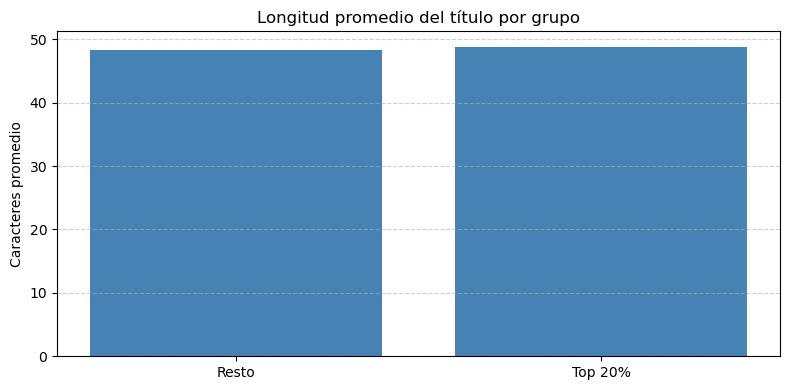

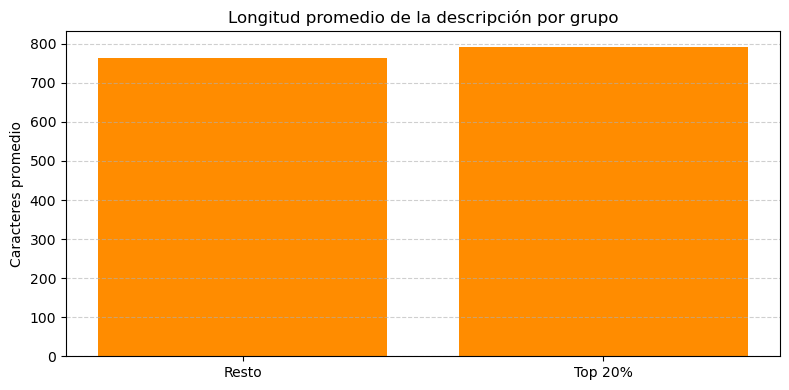

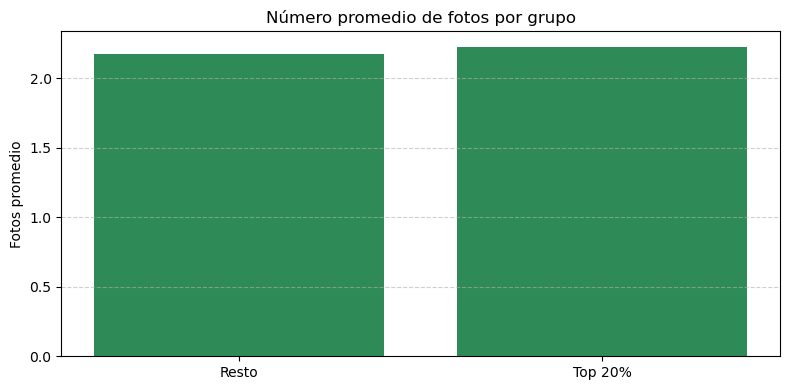

In [17]:
import matplotlib.pyplot as plt

# Gráfico de la longitud promedio del título por grupo
plt.figure(figsize=(8,4))
plt.bar(comparativa['grupo'], comparativa['product_name_lenght'], color='steelblue')
plt.title('Longitud promedio del título por grupo')
plt.ylabel('Caracteres promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico de la longitud promedio de la descripción por grupo
plt.figure(figsize=(8,4))
plt.bar(comparativa['grupo'], comparativa['product_description_lenght'], color='darkorange')
plt.title('Longitud promedio de la descripción por grupo')
plt.ylabel('Caracteres promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico del número promedio de fotos por grupo
plt.figure(figsize=(8,4))
plt.bar(comparativa['grupo'], comparativa['product_photos_qty'], color='seagreen')
plt.title('Número promedio de fotos por grupo')
plt.ylabel('Fotos promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [18]:
# Calculamos el percentil 90 del número de ventas para identificar los productos del top 10 %
percentil_90 = productos_ventas['num_ventas'].quantile(0.9)

# Creamos una nueva columna que clasifica los productos según si pertenecen al top 10 % o al resto
productos_ventas['grupo'] = productos_ventas['num_ventas'].apply(
    lambda x: 'Top 10%' if x >= percentil_90 else 'Resto'
)

# Calculamos la media de longitud del nombre, descripción y número de fotos para cada grupo
comparativa_top10 = (
    productos_ventas
    .groupby('grupo')[['product_name_lenght', 'product_description_lenght', 'product_photos_qty']]
    .mean()
    .reset_index()
)

comparativa_top10

,grupo,product_name_lenght,product_description_lenght,product_photos_qty
0,Resto,48.414920,767.023758,2.174364
1,Top 10%,48.942414,805.049961,2.298712


En la comparación entre el top 10 % de productos más vendidos y el resto apenas se observan diferencias significativas.
Las longitudes promedio del nombre, la descripción y el número de fotos son casi idénticas.

Esto refuerza la idea de que, en este caso, las características del contenido del producto (título, descripción o imágenes) de momento no parecen ser un factor determinante del volumen de ventas.

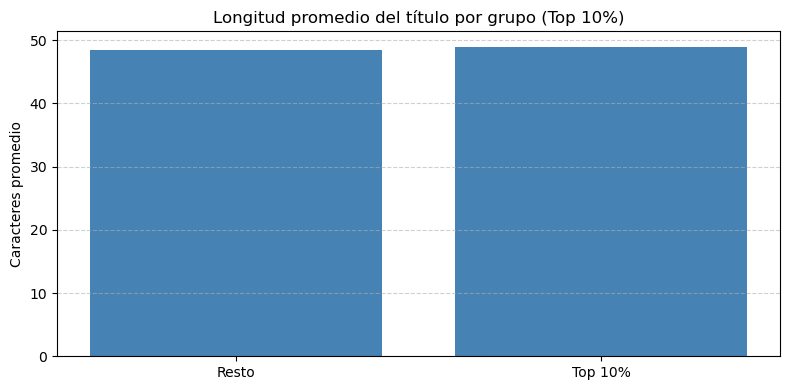

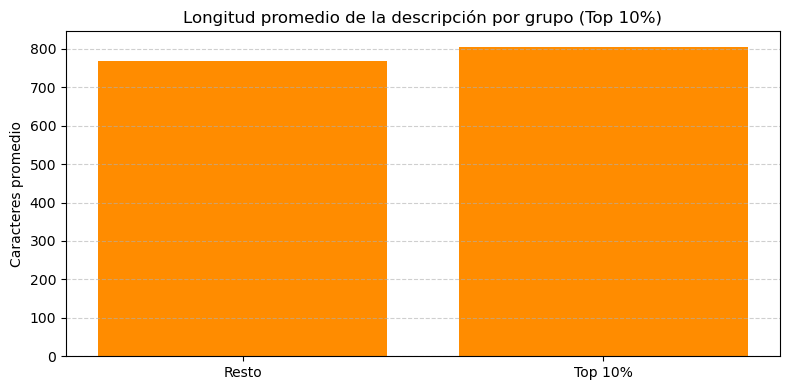

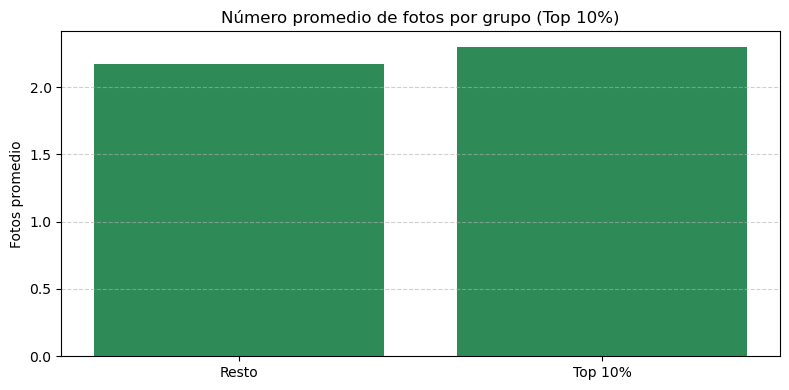

In [19]:
# Gráfico de la longitud promedio del título por grupo (Top 10%)
plt.figure(figsize=(8,4))
plt.bar(comparativa_top10['grupo'], comparativa_top10['product_name_lenght'], color='steelblue')
plt.title('Longitud promedio del título por grupo (Top 10%)')
plt.ylabel('Caracteres promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico de la longitud promedio de la descripción por grupo (Top 10%)
plt.figure(figsize=(8,4))
plt.bar(comparativa_top10['grupo'], comparativa_top10['product_description_lenght'], color='darkorange')
plt.title('Longitud promedio de la descripción por grupo (Top 10%)')
plt.ylabel('Caracteres promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico del número promedio de fotos por grupo (Top 10%)
plt.figure(figsize=(8,4))
plt.bar(comparativa_top10['grupo'], comparativa_top10['product_photos_qty'], color='seagreen')
plt.title('Número promedio de fotos por grupo (Top 10%)')
plt.ylabel('Fotos promedio')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Comparativa por categorías

In [21]:
# Añadimos la categoría original a la tabla de productos con ventas para poder analizar resultados por tipo de producto
productos_ventas_cat = productos_ventas.merge(
    df_products_clean[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

In [22]:
# Añadimos la traducción de la categoría en inglés
productos_ventas_cat = productos_ventas_cat.merge(
    df_product_cat[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)

In [23]:
# Calculamos el percentil 90 de ventas dentro de cada categoría para identificar los productos más vendidos en su propio grupo
productos_ventas_cat['percentil_90'] = productos_ventas_cat.groupby('product_category_name_english')['num_ventas'].transform(
    lambda x: x.quantile(0.9)
)

# Creamos una columna que clasifica cada producto como 'Top 10% categoría' o 'Resto' según su posición dentro de su categoría
productos_ventas_cat['grupo'] = productos_ventas_cat.apply(
    lambda row: 'Top 10% categoría' if row['num_ventas'] >= row['percentil_90'] else 'Resto',
    axis=1
)

In [24]:
# Contamos cuántos productos hay por categoría
productos_por_cat = productos_ventas_cat.groupby('product_category_name_english')['product_id'].nunique()


In [26]:
productos_por_cat.head(10)

product_category_name_english
agro_industry_and_commerce      74
air_conditioning               124
art                             55
arts_and_craftmanship           19
audio                           58
auto                          1900
baby                           919
bed_bath_table                3029
books_general_interest         216
books_imported                  31
Name: product_id, dtype: int64

In [27]:
# Filtramos las categorías que tengan al menos 20 productos distintos para asegurar una muestra representativa
cats_validas = productos_por_cat[productos_por_cat >= 20].index
productos_ventas_cat = productos_ventas_cat[productos_ventas_cat['product_category_name_english'].isin(cats_validas)]


In [28]:
# Calculamos las medias de longitud del nombre, descripción y número de fotos por categoría y grupo (Top 10% vs Resto)
comparativa_categorias = (
    productos_ventas_cat
    .groupby(['product_category_name_english', 'grupo'])[['product_name_lenght', 'product_description_lenght', 'product_photos_qty']]
    .mean()
    .reset_index()
)

comparativa_categorias.head(20)

,product_category_name_english,grupo,product_name_lenght,product_description_lenght,product_photos_qty
0,agro_industry_and_commerce,Resto,49.560606,791.136364,2.287879
1,agro_industry_and_commerce,Top 10% categoría,45.375000,944.875000,2.500000
2,air_conditioning,Resto,51.555556,868.740741,2.111111
3,air_conditioning,Top 10% categoría,52.375000,1132.875000,2.562500
4,art,Resto,46.895833,689.125000,1.895833
5,art,Top 10% categoría,48.428571,604.428571,4.000000
6,audio,Resto,46.923077,769.173077,2.057692
7,audio,Top 10% categoría,43.333333,892.833333,1.833333
8,auto,Resto,52.083284,804.301240,2.645009
9,auto,Top 10% categoría,52.652174,890.946860,2.570048


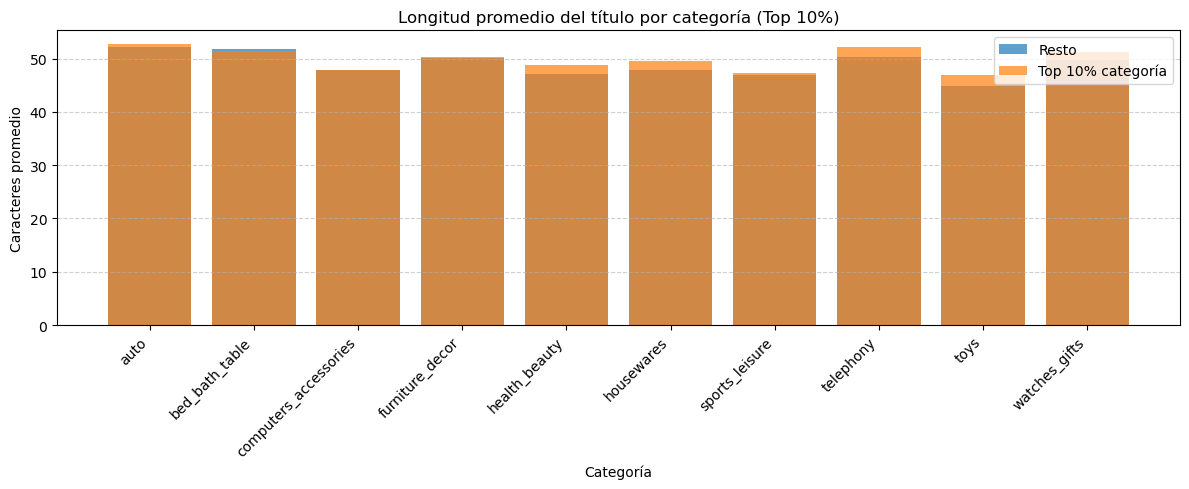

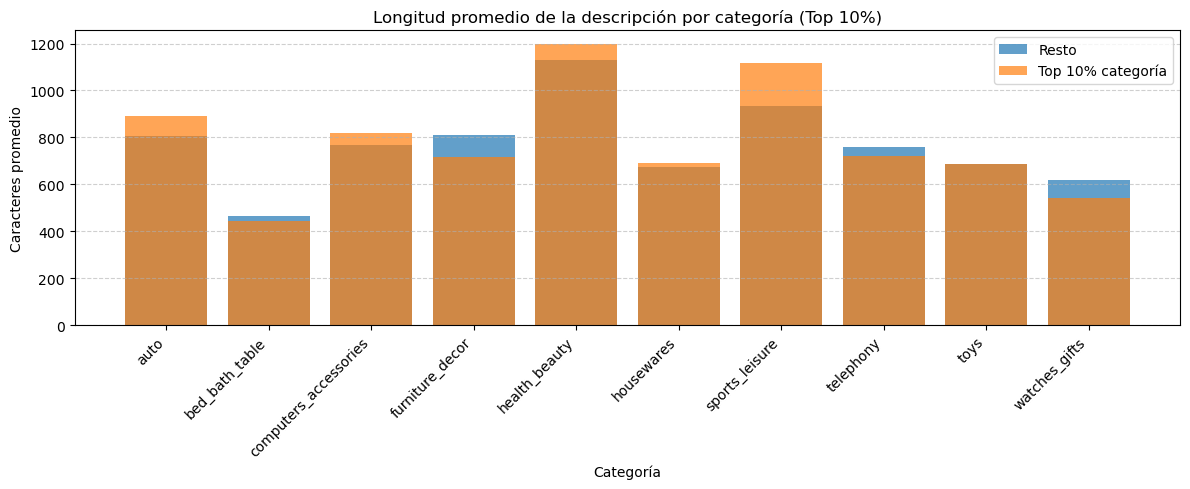

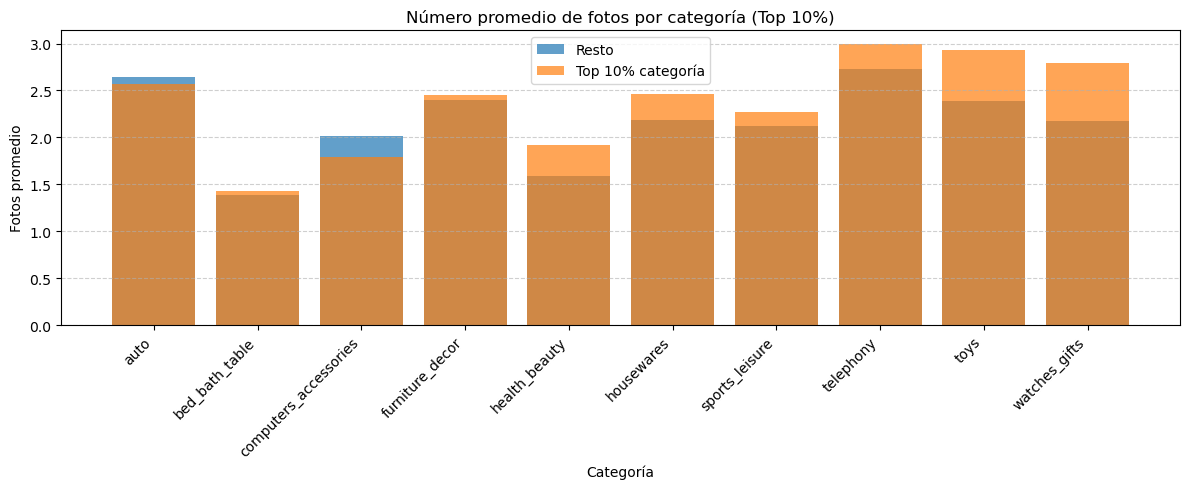

In [29]:
# Seleccionamos las 10 categorías con mayor número de productos para comparar las características de los más vendidos
top_categorias = (
    productos_ventas_cat['product_category_name_english']
    .value_counts()
    .head(10)
    .index
)
df_plot = comparativa_categorias[comparativa_categorias['product_category_name_english'].isin(top_categorias)]

# Gráfico de longitud promedio del título por categoría (Top 10% vs Resto)
plt.figure(figsize=(12,5))
for grupo in df_plot['grupo'].unique():
    subset = df_plot[df_plot['grupo'] == grupo]
    plt.bar(
        subset['product_category_name_english'],
        subset['product_name_lenght'],
        label=grupo,
        alpha=0.7
    )
plt.title('Longitud promedio del título por categoría (Top 10%)')
plt.ylabel('Caracteres promedio')
plt.xlabel('Categoría')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico de longitud promedio de la descripción por categoría (Top 10% vs Resto)
plt.figure(figsize=(12,5))
for grupo in df_plot['grupo'].unique():
    subset = df_plot[df_plot['grupo'] == grupo]
    plt.bar(
        subset['product_category_name_english'],
        subset['product_description_lenght'],
        label=grupo,
        alpha=0.7
    )
plt.title('Longitud promedio de la descripción por categoría (Top 10%)')
plt.ylabel('Caracteres promedio')
plt.xlabel('Categoría')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico del número promedio de fotos por categoría (Top 10% vs Resto)
plt.figure(figsize=(12,5))
for grupo in df_plot['grupo'].unique():
    subset = df_plot[df_plot['grupo'] == grupo]
    plt.bar(
        subset['product_category_name_english'],
        subset['product_photos_qty'],
        label=grupo,
        alpha=0.7
    )
plt.title('Número promedio de fotos por categoría (Top 10%)')
plt.ylabel('Fotos promedio')
plt.xlabel('Categoría')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

No vemos ningún insight evidente en el análisis por categorías

### Comparativa por vendedores

In [30]:
# Unimos la tabla de ventas (order_items) con la de productos limpios para incluir las características de cada producto vendido
df_vendedores_productos = df_order_items.merge(
    df_products_clean[['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']],
    on='product_id',
    how='left'
)

df_vendedores_productos

,id,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty
0,112650,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,47.0,511.0,1.0
1,112649,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,56.0,1306.0,1.0
2,112648,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,43.0,869.0,1.0
3,112647,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,31.0,232.0,1.0
4,112646,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,43.0,1002.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
112645,5,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,59.0,409.0,1.0
112646,4,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,42.0,480.0,1.0
112647,3,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,59.0,695.0,2.0
112648,2,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,56.0,239.0,2.0


In [31]:
# Calculamos el total de ventas y las medias de características de los productos por cada vendedor
vendedores_resumen = (
    df_vendedores_productos
    .groupby('seller_id')
    .agg(
        num_ventas=('order_id', 'count'),
        media_titulo=('product_name_lenght', 'mean'),
        media_descripcion=('product_description_lenght', 'mean'),
        media_fotos=('product_photos_qty', 'mean')
    )
    .reset_index()
)

vendedores_resumen

,seller_id,num_ventas,media_titulo,media_descripcion,media_fotos
0,0015a82c2db000af6aaaf3ae2ecb0532,3,40.000000,849.000000,2.000000
1,001cca7ae9ae17fb1caed9dfb1094831,239,35.841004,472.351464,1.794979
2,001e6ad469a905060d959994f1b41e4f,1,58.000000,413.000000,5.000000
3,002100f778ceb8431b7a1020ff7ab48f,55,55.254545,653.854545,1.000000
4,003554e2dce176b5555353e4f3555ac8,1,NaN,NaN,NaN
...,...,...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,1,35.000000,1306.000000,4.000000
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,20,49.050000,525.300000,1.200000
3092,ffeee66ac5d5a62fe688b9d26f83f534,14,55.357143,801.285714,4.928571
3093,fffd5413c0700ac820c7069d66d98c89,61,43.622951,448.786885,2.573770


In [34]:
# Mostramos el percentil 90 que vamos a utilizar de nuevo
percentil_90

80.0

In [35]:
# Clasificamos a los vendedores en dos grupos: el top 10 % con más ventas y el resto
vendedores_resumen['grupo'] = vendedores_resumen['num_ventas'].apply(
    lambda x: 'Top 10% vendedores' if x >= percentil_90 else 'Resto'
)

In [36]:
# Calculamos la media de las características de los productos vendidos por grupo (Top 10% vs Resto)
comparativa_vendedores = (
    vendedores_resumen
    .groupby('grupo')[['media_titulo', 'media_descripcion', 'media_fotos']]
    .mean()
    .reset_index()
)

# Mostramos la comparativa entre los vendedores top y el resto
print("\nComparativa entre vendedores top y resto:")
comparativa_vendedores


Comparativa entre vendedores top y resto:


,grupo,media_titulo,media_descripcion,media_fotos
0,Resto,46.255002,864.513865,2.252791
1,Top 10% vendedores,48.658760,812.383371,2.211082


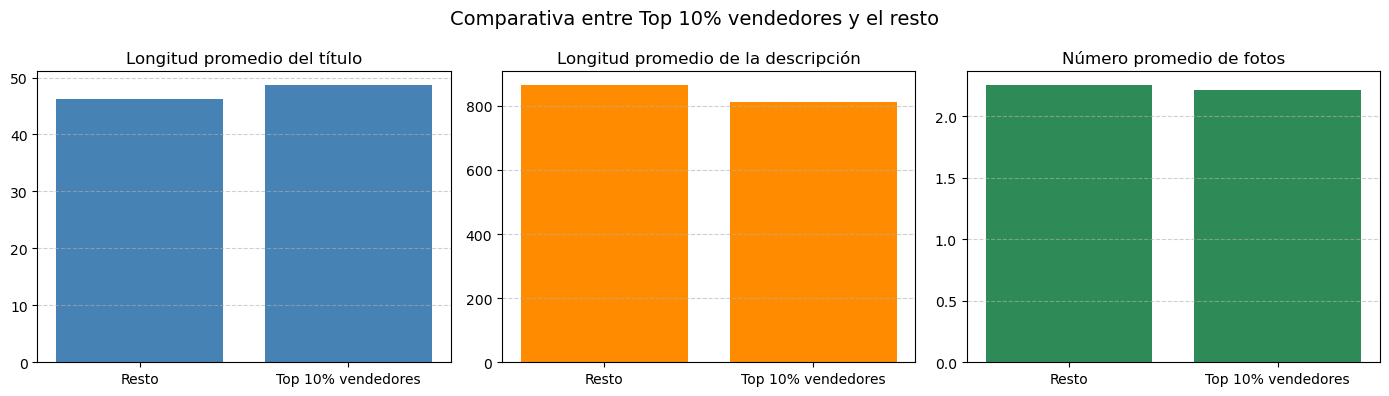

In [37]:
# Visualizamos la comparativa entre el top 10 % de vendedores y el resto según las características promedio de sus productos vendidos

fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].bar(comparativa_vendedores['grupo'], comparativa_vendedores['media_titulo'], color='steelblue')
axes[0].set_title('Longitud promedio del título')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].bar(comparativa_vendedores['grupo'], comparativa_vendedores['media_descripcion'], color='darkorange')
axes[1].set_title('Longitud promedio de la descripción')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

axes[2].bar(comparativa_vendedores['grupo'], comparativa_vendedores['media_fotos'], color='seagreen')
axes[2].set_title('Número promedio de fotos')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Comparativa entre Top 10% vendedores y el resto', fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
# Calculamos el tamaño del Top 10% según el número total de vendedores
import numpy as np
import matplotlib.pyplot as plt

n_sellers = len(vendedores_resumen)
top_n = max(1, int(np.ceil(0.10 * n_sellers)))  # al menos un vendedor en el top

vendedores_resumen = vendedores_resumen.copy()
vendedores_resumen['rank'] = vendedores_resumen['num_ventas'].rank(method='first', ascending=False)
vendedores_resumen['grupo'] = np.where(
    vendedores_resumen['rank'] <= top_n,
    'Top 10% vendedores',
    'Resto'
)

# Verificamos que ambos grupos existan
print(vendedores_resumen['grupo'].value_counts())

grupo
Resto                 2785
Top 10% vendedores     310
Name: count, dtype: int64


In [42]:
# Preparamos los datos para los boxplots (eliminando nulos si los hay)
top_mask = vendedores_resumen['grupo'] == 'Top 10% vendedores'
rest_mask = vendedores_resumen['grupo'] == 'Resto'

titulo_top  = vendedores_resumen.loc[top_mask,  'media_titulo'].dropna()
titulo_rest = vendedores_resumen.loc[rest_mask, 'media_titulo'].dropna()

desc_top  = vendedores_resumen.loc[top_mask,  'media_descripcion'].dropna()
desc_rest = vendedores_resumen.loc[rest_mask, 'media_descripcion'].dropna()

fotos_top  = vendedores_resumen.loc[top_mask,  'media_fotos'].dropna()
fotos_rest = vendedores_resumen.loc[rest_mask, 'media_fotos'].dropna()

/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_84527/3591290815.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([titulo_top, titulo_rest],
/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_84527/3591290815.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([desc_top, desc_rest],
/var/folders/yt/mc_g8dls0932dpx0y1jgfh900000gn/T/ipykernel_84527/3591290815.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([fotos_top, fotos_rest],


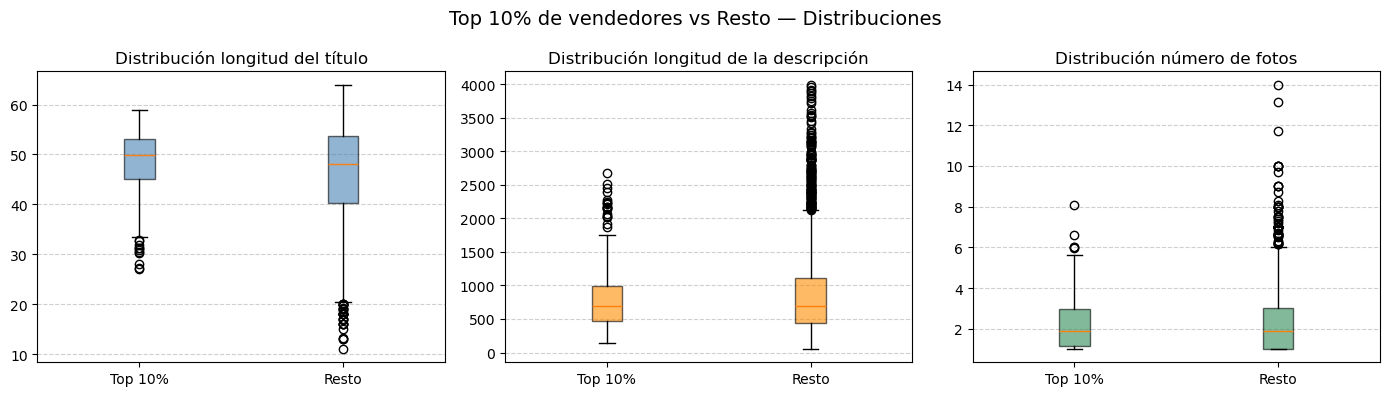

In [44]:
# Visualizamos la distribución de cada métrica por grupo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].boxplot([titulo_top, titulo_rest],
                labels=['Top 10%', 'Resto'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Distribución longitud del título')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].boxplot([desc_top, desc_rest],
                labels=['Top 10%', 'Resto'],
                patch_artist=True,
                boxprops=dict(facecolor='darkorange', alpha=0.6))
axes[1].set_title('Distribución longitud de la descripción')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

axes[2].boxplot([fotos_top, fotos_rest],
                labels=['Top 10%', 'Resto'],
                patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.6))
axes[2].set_title('Distribución número de fotos')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Top 10% de vendedores vs Resto — Distribuciones', fontsize=14)
plt.tight_layout()
plt.show()

### Recomendaciones para optimizar las fichas de producto

Tras analizar miles de productos y comparar a los vendedores top con el resto, aparecen rangos que se repiten en las características de los productos:

Longitud del título
	•	Lo más habitual entre los vendedores que mejor funcionan está entre 45 y 55 caracteres.
	•	Corto pero informativo: suficiente para incluir modelo del producto, tipo de producto y un atributo clave.

Longitud de la descripción
	•	Las descripciones suelen moverse en una orquilla con más longitud 500 y 1100 caracteres.
	•	Por debajo de eso puede ser escasa y por encima puede ser demasiada información.
	•	Las mejores descripciones explican lo necesario sin alargar por alargar.

Número de fotos
	•	La mayoría de vendedores  usan entre 1 y 3 fotos, con la media en 2 imágenes.
	•	Basta con una foto clara del producto, y otra de detalle.

### Relación entre Ventas y el Título, Descripción y Fotos del producto

In [45]:
# Filtramos el dataset para quedarnos únicamente con los pedidos que llegaron al cliente
df_ventas_productos = df_ventas_productos[df_ventas_productos['order_status'] == 'delivered']

In [46]:
# Calculamos las ventas totales y las longitudes promedio del contenido para cada combinación vendedor–producto
ventas_por_vendedor = (
    df_ventas_productos
    .groupby(['product_id', 'seller_id'])
    .agg(
        ventas_totales=('price', 'sum'),
        nombre_promedio=('product_name_lenght', 'mean'),
        descripcion_promedio=('product_description_lenght', 'mean'),
        fotos_promedio=('product_photos_qty', 'mean'),
        num_ventas=('order_id', 'count')
    )
    .reset_index()
)

In [47]:
# Identificamos, para cada producto, qué vendedor acumuló más ventas
top_vendedores = ventas_por_vendedor.loc[
    ventas_por_vendedor.groupby('product_id')['ventas_totales'].idxmax()
].reset_index(drop=True)

# Mostramos una vista resumida de los vendedores líderes por producto
top_vendedores[['product_id', 'seller_id', 'ventas_totales', 'num_ventas',
                'nombre_promedio', 'descripcion_promedio', 'fotos_promedio']].head(10)

,product_id,seller_id,ventas_totales,num_ventas,nombre_promedio,descripcion_promedio,fotos_promedio
0,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,101.65,1,53.0,596.0,6.0
1,00088930e925c41fd95ebfe695fd2655,7142540dd4c91e2237acb7e911c4eba2,129.90,1,56.0,752.0,4.0
2,0009406fd7479715e4bef61dd91f2462,4a3ca9315b744ce9f8e9374361493884,229.00,1,50.0,266.0,2.0
3,000b8f95fcb9e0096488278317764d19,40ec8ab6cdafbcc4f544da38c67da39a,117.80,2,25.0,364.0,3.0
4,000d9be29b5207b54e86aa1b1ac54872,8ae520247981aa06bc94abddf5f46d34,199.00,1,48.0,613.0,4.0
5,0011c512eb256aa0dbbb544d8dffcf6e,b4ffb71f0cb1b1c3d63fad021ecf93e1,52.00,1,58.0,177.0,1.0
6,00126f27c813603687e6ce486d909d01,cd68562d3f44870c08922d380acae552,498.00,2,42.0,2461.0,1.0
7,001795ec6f1b187d37335e1c4704762e,8b321bb669392f5163d04c59e235e066,350.10,9,53.0,274.0,1.0
8,001b237c0e9bb435f2e54071129237e9,d2374cbcbb3ca4ab1086534108cc3ab7,78.90,1,42.0,253.0,1.0
9,001b72dfd63e9833e8c02742adf472e3,8a32e327fe2c1b3511609d81aaf9f042,454.87,13,45.0,520.0,3.0


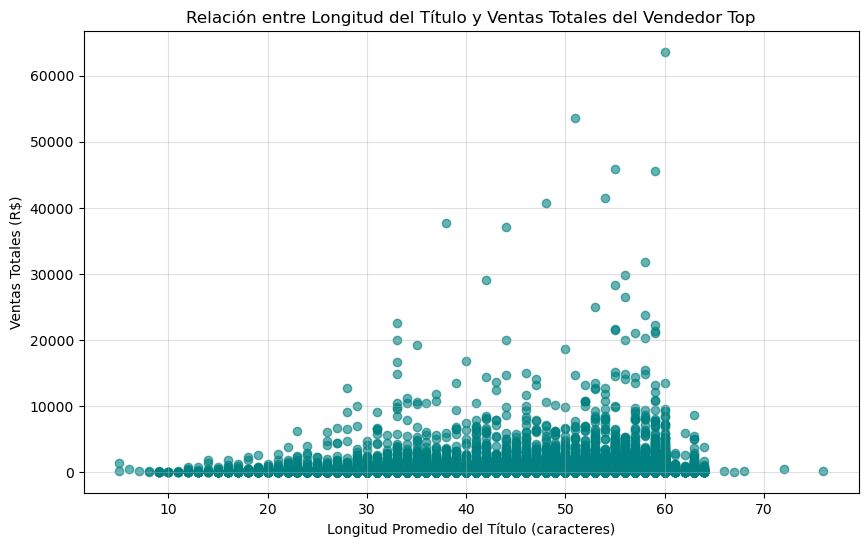

In [48]:
# Representamos si la longitud media del título está relacionada con las ventas totales del vendedor líder por producto
plt.figure(figsize=(10, 6))
plt.scatter(top_vendedores['nombre_promedio'], top_vendedores['ventas_totales'], alpha=0.6, color='teal')
plt.title('Relación entre Longitud del Título y Ventas Totales del Vendedor Top')
plt.xlabel('Longitud Promedio del Título (caracteres)')
plt.ylabel('Ventas Totales (R$)')
plt.grid(alpha=0.4)
plt.show()

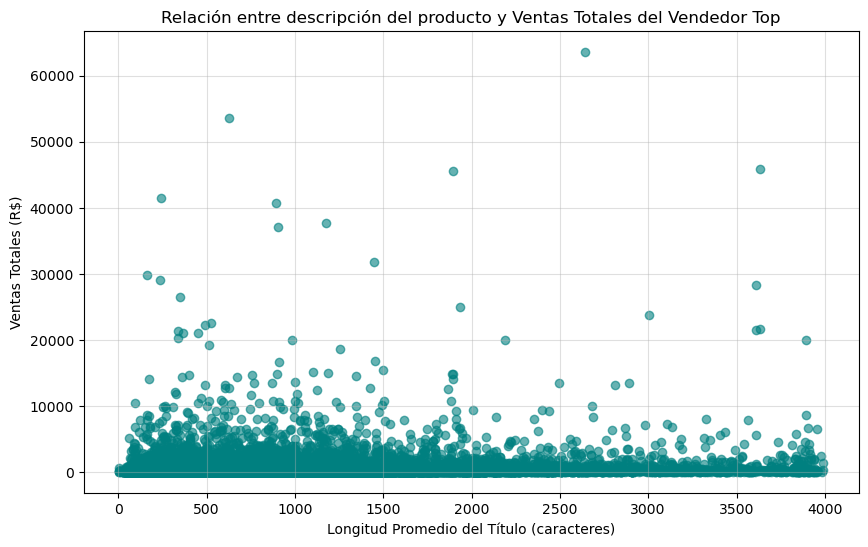

In [51]:
# Exploramos si la longitud media de la descripción del producto guarda relación con las ventas totales del vendedor lider
plt.figure(figsize=(10, 6))
plt.scatter(top_vendedores['descripcion_promedio'], top_vendedores['ventas_totales'], alpha=0.6, color='teal')
plt.title('Relación entre descripción del producto y Ventas Totales del Vendedor Top')
plt.xlabel('Longitud Promedio del Título (caracteres)')
plt.ylabel('Ventas Totales (R$)')
plt.grid(alpha=0.4)
plt.show()

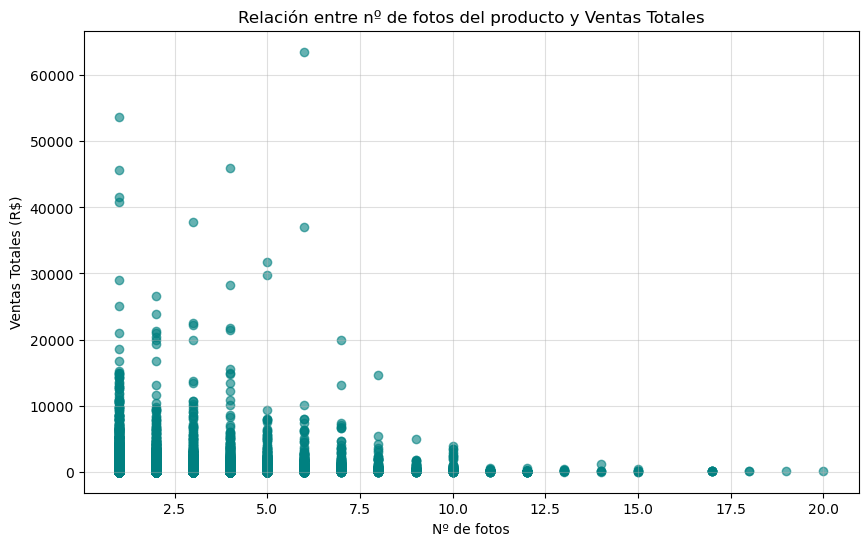

In [50]:
# Evaluamos si el número medio de fotos del producto influye en las ventas del vendedor líder por producto
plt.figure(figsize=(10, 6))
plt.scatter(top_vendedores['fotos_promedio'], top_vendedores['ventas_totales'], alpha=0.6, color='teal')
plt.title('Relación entre nº de fotos del producto y Ventas Totales')
plt.xlabel('Nº de fotos')
plt.ylabel('Ventas Totales (R$)')
plt.grid(alpha=0.4)
plt.show()

Recomendaciones basadas en los patrones que  aparecen en los datos

Los scatterplots no muestran una relación “cuanto más largo, más ventas”, pero sí dejan ver zonas donde se concentra la mayoría de productos que venden bien. Ese es el punto útil para un vendedor.

1. Título: el rango donde se mueve casi todo lo que vende

La nube es clara:
la mayoría de títulos (y también muchas de las mejores ventas) están entre 40 y 60 caracteres.
	•	Es un rango donde caben: modelo + tipo de producto + un detalle relevante.

Recomendación: apunta a 40–60 caracteres.

2. Descripción: gran parte de los productos se queda por debajo de 1500 caracteres

Aquí la dispersión es enorme, pero si que se puede ver mayor volumen en un rango razonable:
	•	Muchísimos productos se mueven entre 0 y 1500 caracteres, especialmente con ventas un poco más altas.

Recomendación: mantener la descripción en un rango 500–1500 caracteres es más que suficiente.

3. Fotos: la mayoría de vendedores (incluidos los top) se quedan en 1–3

Este es el patrón más limpio:
	•	Casi todos los productos,están entre 1 y 3 fotos.
	•	A partir de 4–5 las ventas no suben; de hecho, cuanto más fotos más se acercan a 0.